In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import h5py
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 设置科学计数法格式
plt.rcParams['axes.formatter.useoffset'] = False
plt.rcParams['axes.formatter.use_mathtext'] = True

print("库导入完成")

/home/yanleizh/.conda/envs/pypsa-china/lib/python3.12/site-packages/seaborn/_statistics.py:32: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.3.1)
  from scipy.stats import gaussian_kde


库导入完成


In [2]:
# 文件路径
file1_path = "/p/tmp/yanleizh/PyPSA-China-PIK/resources/derived_data/overnight_co2pw-SSP2-PkBudg1000-CHA-pypsaelh2_topo-current+FCG/load/regio_hrly_ac_load_2060.h5"
file2_path = "/p/tmp/yanleizh/PyPSA-China-PIK/resources/derived_data/overnight_co2pw-SSP2-PkBudg1000-CHA-pypsaelh2_topo-current+FCG/load/integrated_load_2060.h5"

print(f"文件1: {file1_path}")
print(f"文件2: {file2_path}")
# 检查文件结构
def explore_h5_structure(file_path, file_name):
    print(f"\n=== {file_name} 结构 ===")
    with h5py.File(file_path, 'r') as f:
        def print_structure(name, obj):
            if isinstance(obj, h5py.Dataset):
                print(f"  {name}: shape={obj.shape}, dtype={obj.dtype}")
            elif isinstance(obj, h5py.Group):
                print(f"  {name}/ (Group)")
        f.visititems(print_structure)

explore_h5_structure(file1_path, "regio_hrly_ac_load_2060.h5")
explore_h5_structure(file2_path, "integrated_load_2060.h5")

文件1: /p/tmp/yanleizh/PyPSA-China-PIK/resources/derived_data/overnight_co2pw-SSP2-PkBudg1000-CHA-pypsaelh2_topo-current+FCG/load/regio_hrly_ac_load_2060.h5
文件2: /p/tmp/yanleizh/PyPSA-China-PIK/resources/derived_data/overnight_co2pw-SSP2-PkBudg1000-CHA-pypsaelh2_topo-current+FCG/load/integrated_load_2060.h5

=== regio_hrly_ac_load_2060.h5 结构 ===
  load/ (Group)
  load/axis0: shape=(31,), dtype=|S13
  load/axis1: shape=(8760,), dtype=int64
  load/block0_items: shape=(31,), dtype=|S13
  load/block0_values: shape=(8760, 31), dtype=float64

=== integrated_load_2060.h5 结构 ===
  load/ (Group)
  load/axis0: shape=(31,), dtype=|S13
  load/axis1: shape=(8760,), dtype=int64
  load/block0_items: shape=(31,), dtype=|S13
  load/block0_values: shape=(8760, 31), dtype=float64


In [3]:
import h5py

def find_first_dataset(group, prefix=""):
    """
    递归在 HDF5 文件/组中查找第一个 Dataset。
    返回 (dataset, path)，找不到返回 (None, None)
    """
    for key in group.keys():
        obj = group[key]
        path = f"{prefix}/{key}" if prefix else key
        if isinstance(obj, h5py.Dataset):
            return obj, path
        elif isinstance(obj, h5py.Group):
            ds, ds_path = find_first_dataset(obj, path)
            if ds is not None:
                return ds, ds_path
    return None, None

def load_h5_data(file_path):
    """读取 H5 文件数据"""
    with h5py.File(file_path, 'r') as f:
        # 先试几个常见的键
        possible_keys = ['load', 'data', 'values', 'loads']
        for key in possible_keys:
            if key in f and isinstance(f[key], h5py.Dataset):
                print(f"找到数据键: {key}")
                return f[key][:]

        # 没找到就递归寻找第一个 Dataset
        dataset, path = find_first_dataset(f)
        if dataset is not None:
            print(f"使用数据集: {path}")
            return dataset[:]
        else:
            print("没有找到任何 Dataset！")
            return None

# 示例调用
print("正在读取数据...")
data1 = load_h5_data(file1_path)
data2 = load_h5_data(file2_path)

print(f"\n数据1形状: {data1.shape if data1 is not None else 'None'}")
print(f"数据2形状: {data2.shape if data2 is not None else 'None'}")


正在读取数据...
使用数据集: load/axis0
使用数据集: load/axis0

数据1形状: (31,)
数据2形状: (31,)


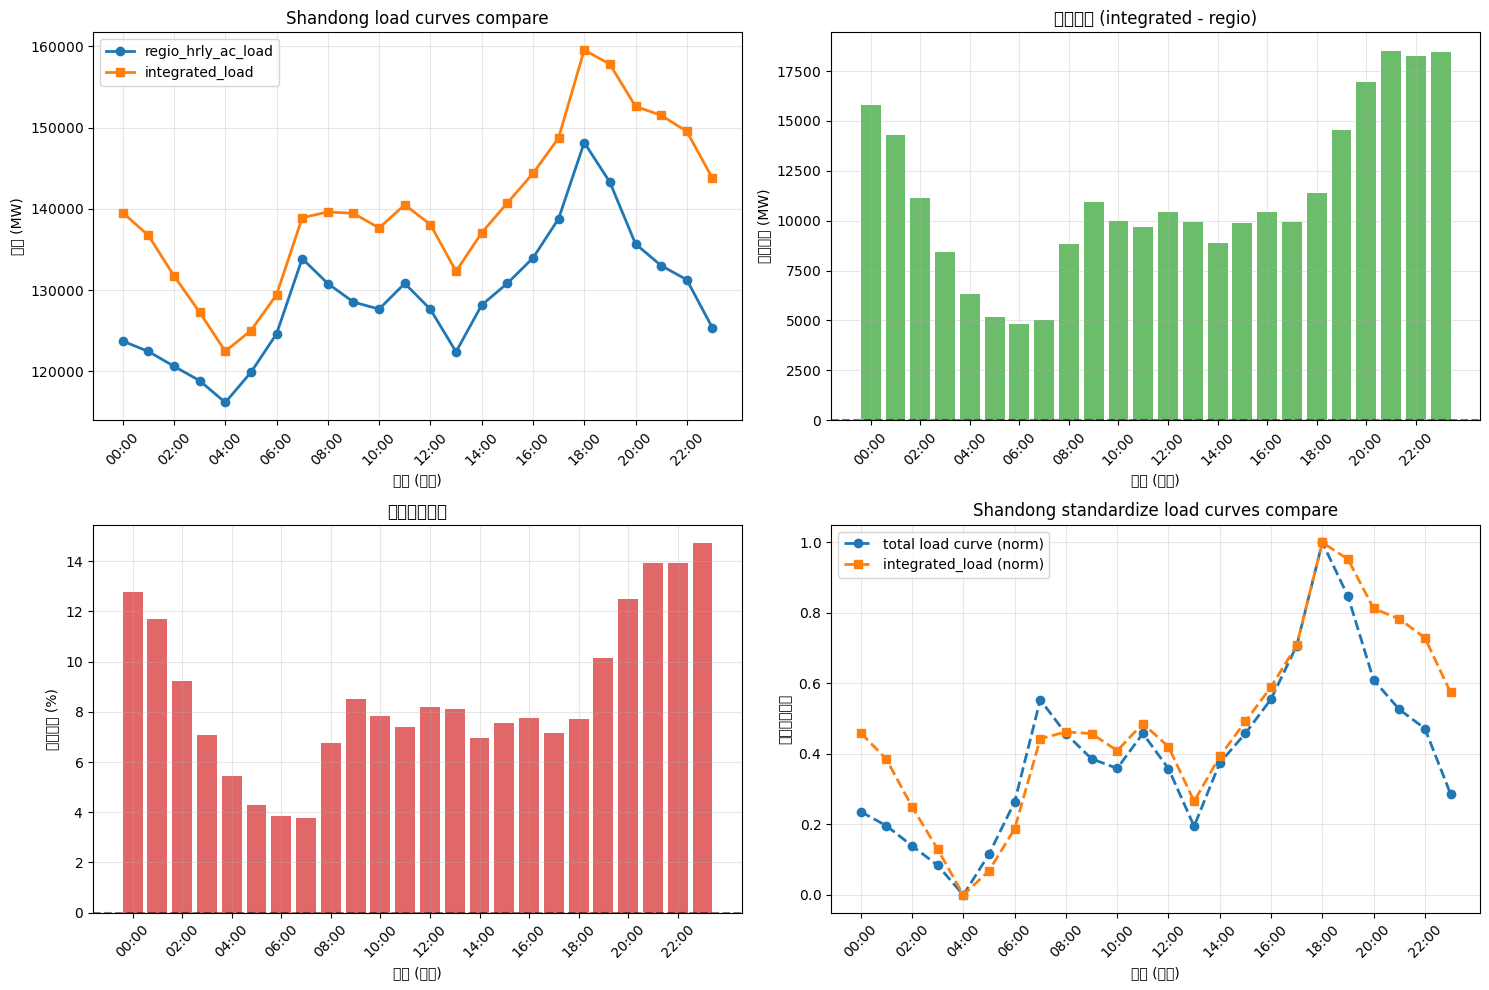

蓝线 峰谷差比例: 0.25, 峰谷比: 1.28
橙线 峰谷差比例: 0.26, 峰谷比: 1.30


In [ ]:
import numpy as np
import h5py
import matplotlib.pyplot as plt

# ---------------- 读取数据 ----------------
with h5py.File(file1_path, 'r') as f1, h5py.File(file2_path, 'r') as f2:
    regions = [name.decode('utf-8') for name in f1['load/axis0'][:]]
    target_region = 'Shandong'
    idx = regions.index(target_region)
    values1 = f1['load/block0_values'][:]  # (8760, 31)
    values2 = f2['load/block0_values'][:]

# ---------------- 提取前24小时数据 ----------------
first_day_1 = values1[:24, idx]
first_day_2 = values2[:24, idx]

# ---------------- 时间轴 ----------------
hours = np.arange(24)
time_labels = [f"{h:02d}:00" for h in hours]

# ---------------- 颜色方案 ----------------
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

# -------- 标准化 --------
norm_1 = (first_day_1 - first_day_1.min()) / (first_day_1.max() - first_day_1.min())
norm_2 = (first_day_2 - first_day_2.min()) / (first_day_2.max() - first_day_2.min())

plt.figure(figsize=(15, 10))

# 曲线比较
plt.subplot(2, 2, 1)
plt.plot(hours, first_day_1, 'o-', color=colors[0], linewidth=2, markersize=6, label='regio_hrly_ac_load')
plt.plot(hours, first_day_2, 's-', color=colors[1], linewidth=2, markersize=6, label='integrated_load')
plt.xlabel('时间 (小时)')
plt.ylabel('负荷 (MW)')
plt.title(f'{target_region} load curves compare')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(hours[::2], time_labels[::2], rotation=45)

# 差异
plt.subplot(2, 2, 2)
difference = first_day_2 - first_day_1
plt.bar(hours, difference, color=colors[2], alpha=0.7)
plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)
plt.xlabel('时间 (小时)')
plt.ylabel('负荷差异 (MW)')
plt.title('负荷差异 (integrated - regio)')
plt.grid(True, alpha=0.3)
plt.xticks(hours[::2], time_labels[::2], rotation=45)

# 相对差异
plt.subplot(2, 2, 3)
relative_diff = (difference / first_day_1) * 100
plt.bar(hours, relative_diff, color=colors[3], alpha=0.7)
plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)
plt.xlabel('时间 (小时)')
plt.ylabel('相对差异 (%)')
plt.title('相对负荷差异')
plt.grid(True, alpha=0.3)
plt.xticks(hours[::2], time_labels[::2], rotation=45)

# 标准化曲线对比
plt.subplot(2, 2, 4)
plt.plot(hours, norm_1, 'o--', color=colors[0], linewidth=2, markersize=6, label='total load curve (norm)')
plt.plot(hours, norm_2, 's--', color=colors[1], linewidth=2, markersize=6, label='integrated_load (norm)')
plt.xlabel('时间 (小时)')
plt.ylabel('标准化后负荷')
plt.title(f'{target_region} standardize load curves compare')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(hours[::2], time_labels[::2], rotation=45)

plt.tight_layout()
plt.show()

# 假设 first_day_1 和 first_day_2 已经在手
peak_blue = first_day_1.max()
valley_blue = first_day_1.min()
mean_blue = first_day_1.mean()
diff_blue = peak_blue - valley_blue
ratio_blue = diff_blue / mean_blue
pv_blue = peak_blue / valley_blue

peak_orange = first_day_2.max()
valley_orange = first_day_2.min()
mean_orange = first_day_2.mean()
diff_orange = peak_orange - valley_orange
ratio_orange = diff_orange / mean_orange
pv_orange = peak_orange / valley_orange

print(f"蓝线 峰谷差比例: {ratio_blue:.2f}, 峰谷比: {pv_blue:.2f}")
print(f"橙线 峰谷差比例: {ratio_orange:.2f}, 峰谷比: {pv_orange:.2f}")
### EV share curve### 2030 and 2060
### yearly load curve duration 
### national



In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import h5py
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 设置科学计数法格式
plt.rcParams['axes.formatter.useoffset'] = False
plt.rcParams['axes.formatter.use_mathtext'] = True

print("库导入完成")

库导入完成
